# Crossy Road — trening agenta PPO na własnym środowisku Gymnasium

**Projekt 4: Własne środowisko (Inteligencja obliczeniowa)**

## Autorzy

|              | Autor 1                          | Autor 2                          |
|--------------|----------------------------------|----------------------------------|
| Imię i nazwisko | Patryk Chamera                | Karol Bystrek                    |
| E-mail       | pchamera@student.agh.edu.pl      | karbystrek@student.agh.edu.pl    |

---

Notebook prezentuje **pełen pipeline uczenia ze wzmocnieniem** (Reinforcement Learning) na własnym środowisku Gymnasium imitującym uproszczoną grę Crossy Road. 

## Spis treści

1. **Setup** — instalacja zależności i importy
2. **Środowisko Gymnasium** — definicja własnego env (50×8 grid, samochody, rzeki)
3. **Sanity check** — losowy agent, weryfikacja API
4. **Agent regułowy** (`StrategicCrossyAgent`) — baseline do porównania
5. **Trening PPO** — Stable-Baselines3, 4 środowiska równolegle, callbacki
6. **Krzywe uczenia** — reward / długość epizodu / reward vs timesteps
7. **Ewaluacja ilościowa** — N=50 epizodów, statystyki, histogramy
8. **Historia iteracji** — 4 rundy reward shapingu z analizą każdej
9. **Wnioski**
10. **Demo gameplay (YouTube)** — wytrenowany agent w akcji

## Środowisko

- **Plansza**: 50 wierszy × 8 kolumn, kafelki: trawa / droga (z autami) / rzeka (z liliami).
- **Akcje**: `Discrete(4)` — UP / DOWN / LEFT / RIGHT.
- **Obserwacje** (3 tryby): `grid`, `large_discrete` (~808 cech), **`local`** (~160 cech, używany w treningu).
- **Reward shape** (po 4 iteracjach): `+1` forward, `−0.1` per step, `−5` death, `+0.05` survival na drodze/rzece.

## Algorytm

- **PPO** (Proximal Policy Optimization) z `MultiInputPolicy` dla `Dict` obserwacji.
- Sieć `[256, 256]` (policy i value head), 4 środowiska równoległe (`DummyVecEnv`).
- Linear LR schedule (`3e-4 → 0`), `ent_coef = 0.1` (silna eksploracja).
- 200 000 timesteps domyślnie (~15–20 min na CPU).

## 1. Setup — instalacja zależności i importy

In [22]:
# Colab: odkomentuj ponizsza linie. Lokalnie, jesli juz masz zainstalowane zaleznosci -- pomin.
!pip install -q "gymnasium>=0.29" "stable-baselines3>=2.3" matplotlib pandas tensorboard
print("test venv")

test venv


In [23]:
from __future__ import annotations

import os
import statistics
import sys
from dataclasses import dataclass, field
from enum import IntEnum
from pathlib import Path
from typing import Any, Optional

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gymnasium import spaces
from gymnasium.envs.registration import register

import stable_baselines3
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import CheckpointCallback, EvalCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv

print(f"Python:             {sys.version.split()[0]}")
print(f"Gymnasium:          {gym.__version__}")
print(f"Stable-Baselines3:  {stable_baselines3.__version__}")
print(f"NumPy:              {np.__version__}")

Python:             3.12.10
Gymnasium:          1.2.3
Stable-Baselines3:  2.8.0
NumPy:              2.4.4


## 2. Środowisko Gymnasium

Definicja własnego środowiska Crossy Road. Wszystkie komponenty (stałe, konfiguracja, encja `Lane`, generator `LaneFactory`,
silnik `CrossyRoadEngine`, wrapper `CrossyRoadEnv`) są zdefiniowane inline

### 2.1 Stałe 

In [24]:
class CellID(IntEnum):
    GRASS = 0
    ROAD = 1
    CAR = 2
    RIVER = 3
    LILY_PAD = 4
    AGENT = 5


class TerrainType(IntEnum):
    GRASS = CellID.GRASS
    ROAD = CellID.ROAD
    RIVER = CellID.RIVER


class ActionID(IntEnum):
    UP = 0
    DOWN = 1
    LEFT = 2
    RIGHT = 3


ACTION_DELTAS = {
    ActionID.UP: (0, 1),
    ActionID.DOWN: (0, -1),
    ActionID.LEFT: (-1, 0),
    ActionID.RIGHT: (1, 0),
}

ANSI_SYMBOLS = {
    CellID.GRASS: ".",
    CellID.ROAD: "=",
    CellID.CAR: "C",
    CellID.RIVER: "~",
    CellID.LILY_PAD: "O",
    CellID.AGENT: "A",
}

### 2.2 `GameConfig` — konfiguracja gry i nagród

Reward shape jest **wynikiem 4 iteracji eksperymentów** (szczegóły w sekcji 8). Wartości tutaj to **runda 4** —
najlepsza znaleziona konfiguracja, która zmusza agenta do strategicznego unikania samochodów zamiast stania
albo szarży kamikadze.

| Parametr | Wartość | Rola |
|---|---|---|
| `reward_forward` | `+1.0` | nagroda za skuteczny ruch UP (ze scrollem planszy) |
| `reward_step` | `−0.1` | per-step penalty — stanie 200 kroków = −20, gorsze niż śmierć |
| `reward_death` | `−5.0` | śmierć kosztowna — `EV(forward przy 80% live) = −0.28`, agent woli unik |
| `reward_survival` | `+0.05` | bonus za przeżycie kroku na drodze/rzece — czekanie staje się 0-rewardowe |

In [25]:
@dataclass(frozen=True)
class GameConfig:
    width: int = 8
    height: int = 50

    # Reward shape (po 4 rundach iteracji)
    reward_forward: float = 1.0
    reward_death: float = -5.0
    reward_step: float = -0.1
    reward_survival: float = 0.05

    # Generacja planszy
    terrain_probs: tuple[float, float, float] = (0.45, 0.33, 0.22)  # grass, road, river
    road_density_range: tuple[float, float] = (0.12, 0.26)
    river_density_range: tuple[float, float] = (0.45, 0.72)
    lane_speed_values: tuple[int, ...] = (2, 3)  # interwal ruchu lilii (auta zawsze co 1)
    safe_start_rows: int = 3                     # 3 dolne wiersze zawsze trawa

### 2.3 `Lane` i `LaneFactory` — pasma planszy i ich generacja

Każdy wiersz planszy to `Lane` — może być trawą (statyczna), drogą (z autami poruszającymi się co 1 tick) albo
rzeką (z liliami poruszającymi się co 2 lub 3 ticki). `LaneFactory` losuje pasma zgodnie z `terrain_probs`.

In [26]:
@dataclass
class Lane:
    terrain: TerrainType
    direction: int = 0
    move_interval: int = 1
    actors: set[int] = field(default_factory=set)
    tick: int = 0

    def step(self, width: int) -> int:
        if self.terrain == TerrainType.GRASS:
            return 0
        self.tick += 1
        if self.tick % self.move_interval != 0 or not self.actors:
            return 0
        self.actors = {((x + self.direction) % width) for x in self.actors}
        return self.direction


class LaneFactory:
    def __init__(self, config: GameConfig):
        self.config = config

    def create_lane(self, rng: np.random.Generator) -> Lane:
        terrain = rng.choice(
            [TerrainType.GRASS, TerrainType.ROAD, TerrainType.RIVER],
            p=self.config.terrain_probs,
        )
        if terrain == TerrainType.GRASS:
            return Lane(terrain=TerrainType.GRASS)

        direction = int(rng.choice([-1, 1]))
        move_interval = (
            1
            if terrain == TerrainType.ROAD
            else int(rng.choice(self.config.lane_speed_values))
        )
        density = self._density_for_terrain(terrain, rng)
        actors = {x for x in range(self.config.width) if rng.random() < density}
        actors = self._normalize_actor_count(terrain=terrain, actors=actors, rng=rng)
        return Lane(
            terrain=terrain,
            direction=direction,
            move_interval=move_interval,
            actors=actors,
        )

    def _density_for_terrain(self, terrain: TerrainType, rng: np.random.Generator) -> float:
        if terrain == TerrainType.ROAD:
            lo, hi = self.config.road_density_range
            return float(rng.uniform(lo, hi))
        lo, hi = self.config.river_density_range
        return float(rng.uniform(lo, hi))

    def _normalize_actor_count(self, terrain, actors, rng):
        width = self.config.width
        if terrain == TerrainType.ROAD:
            min_count, max_count = 1, max(1, width - 2)
        elif terrain == TerrainType.RIVER:
            min_count, max_count = 2, max(2, width - 1)
        else:
            return actors
        if len(actors) < min_count:
            actors = set(rng.choice(width, size=min_count, replace=False).tolist())
        elif len(actors) > max_count:
            chosen = rng.choice(list(actors), size=max_count, replace=False)
            actors = set(chosen.tolist())
        return actors

### 2.4 `CrossyRoadEngine` — rdzeń logiki gry

Implementuje:
- ruch agenta z bottom-buffer (najniższy wiersz to "ślad" — pokazuje skąd przyszedł, ale nowe scrolle nie schodzą poniżej),
- scroll planszy przy ruchu w przód (UP) — zawsze widać kolejne 49 wierszy przed sobą,
- detekcję kolizji (auto na drodze / utonięcie poza lilią na rzece / wypchnięcie poza planszę przez prąd rzeki),
- 3 rodzaje obserwacji: pełny `grid`, `large_discrete` (pełny + dynamika pasm), **`local`** (tylko 10 najbliższych rzędów, używane w treningu).

In [27]:
class CrossyRoadEngine:
    def __init__(self, config: GameConfig):
        self.config = config
        self.factory = LaneFactory(config=config)
        self.lanes: list[Lane] = []
        self.agent_x = config.width // 2
        self.agent_y = self._bottom_buffer_row()
        self.score = 0
        self.steps = 0
        self.terminated = False

    def _bottom_buffer_row(self) -> int:
        return min(1, self.config.height - 1)

    def reset(self, rng: np.random.Generator) -> None:
        safe_rows = min(self.config.safe_start_rows, self.config.height)
        self.lanes = [Lane(terrain=TerrainType.GRASS) for _ in range(safe_rows)]
        for _ in range(self.config.height - safe_rows):
            self.lanes.append(self.factory.create_lane(rng))
        self.agent_x = self.config.width // 2
        self.agent_y = self._bottom_buffer_row()
        self.score = 0
        self.steps = 0
        self.terminated = False

    def _in_bounds(self, x: int, y: int) -> bool:
        return 0 <= x < self.config.width and 0 <= y < self.config.height

    def _scroll_world(self, rng: np.random.Generator) -> None:
        self.lanes.pop(0)
        self.lanes.append(self.factory.create_lane(rng))
        self.agent_y = max(self._bottom_buffer_row(), self.agent_y - 1)

    def step(self, action: int, rng: np.random.Generator) -> tuple[float, bool]:
        if self.terminated:
            raise RuntimeError("Episode already terminated. Call reset().")

        self.steps += 1
        reward = float(self.config.reward_step)  # baseline penalty -- stanie nie jest darmowe
        action_id = ActionID(action)
        dx, dy = ACTION_DELTAS[action_id]

        next_x = self.agent_x + dx
        next_y = self.agent_y + dy
        moved_forward = False
        if self._in_bounds(next_x, next_y):
            self.agent_x = next_x
            self.agent_y = next_y
            moved_forward = dy > 0 and self.agent_y > self._bottom_buffer_row()

        if moved_forward:
            reward += float(self.config.reward_forward)
            self.score += 1
            self._scroll_world(rng)

        # Przesun wszystkie pasma; zapisz ruch pasma agenta (potrzebny dla rzeki).
        lane_shift = 0
        for lane_index, lane in enumerate(self.lanes):
            shift = lane.step(self.config.width)
            if lane_index == self.agent_y:
                lane_shift = shift

        # Rzeka -- agent dryfuje z lilia na ktorej stoi.
        current = self.lanes[self.agent_y]
        if current.terrain == TerrainType.RIVER and lane_shift != 0:
            self.agent_x += lane_shift
            if not (0 <= self.agent_x < self.config.width):
                self.agent_x = min(max(self.agent_x, 0), self.config.width - 1)
                self.terminated = True
                return float(self.config.reward_death), True

        # Detekcja kolizji
        actors = current.actors
        hit_car = current.terrain == TerrainType.ROAD and self.agent_x in actors
        drown = current.terrain == TerrainType.RIVER and self.agent_x not in actors
        if hit_car or drown:
            self.terminated = True
            return float(self.config.reward_death), True

        # Survival bonus -- agent przezyl krok na hazardowym kafelku
        if current.terrain in {TerrainType.ROAD, TerrainType.RIVER}:
            reward += float(self.config.reward_survival)

        return reward, False

    def base_grid(self) -> np.ndarray:
        grid = np.zeros((self.config.height, self.config.width), dtype=np.int32)
        for y, lane in enumerate(self.lanes):
            if lane.terrain == TerrainType.GRASS:
                grid[y, :] = CellID.GRASS
            elif lane.terrain == TerrainType.ROAD:
                grid[y, :] = CellID.ROAD
                for x in lane.actors:
                    grid[y, x] = CellID.CAR
            else:
                grid[y, :] = CellID.RIVER
                for x in lane.actors:
                    grid[y, x] = CellID.LILY_PAD
        return grid

    def grid_observation(self) -> np.ndarray:
        grid = self.base_grid()
        grid[self.agent_y, self.agent_x] = CellID.AGENT
        return grid

    def lane_directions(self) -> np.ndarray:
        out = np.zeros(self.config.height, dtype=np.int32)
        for y, lane in enumerate(self.lanes):
            out[y] = 0 if lane.direction == -1 else 1 if lane.direction == 0 else 2
        return out

    def lane_speeds(self) -> np.ndarray:
        out = np.zeros(self.config.height, dtype=np.int32)
        for y, lane in enumerate(self.lanes):
            out[y] = 0 if lane.terrain == TerrainType.GRASS else lane.move_interval
        return out

    def local_observation(self, view_height: int) -> dict:
        """Cropped obs: tylko `view_height` najnizszych rzedow + dynamika tych pasm.

        Zmniejsza wymiar obserwacji ~5x (z 808 do 160 cech po one-hot) -- siec uczy sie
        tylko tego co istotne (otoczenie agenta), nie marnuje pojemnosci na odlegle rzedy.
        """
        h = min(view_height, self.config.height)
        grid = np.zeros((h, self.config.width), dtype=np.int32)
        lane_dirs = np.zeros(h, dtype=np.int32)
        lane_speeds = np.zeros(h, dtype=np.int32)
        for y in range(h):
            lane = self.lanes[y]
            if lane.terrain == TerrainType.GRASS:
                grid[y, :] = CellID.GRASS
            elif lane.terrain == TerrainType.ROAD:
                grid[y, :] = CellID.ROAD
                for x in lane.actors:
                    grid[y, x] = CellID.CAR
            else:
                grid[y, :] = CellID.RIVER
                for x in lane.actors:
                    grid[y, x] = CellID.LILY_PAD
            lane_dirs[y] = 0 if lane.direction == -1 else 1 if lane.direction == 0 else 2
            lane_speeds[y] = 0 if lane.terrain == TerrainType.GRASS else lane.move_interval

        if 0 <= self.agent_y < h:
            grid[self.agent_y, self.agent_x] = CellID.AGENT

        clamped_y = max(0, min(1, self.agent_y))
        return {
            "grid": grid,
            "lane_directions": lane_dirs,
            "lane_speeds": lane_speeds,
            "agent_position": np.array([clamped_y, self.agent_x], dtype=np.int32),
        }

### 2.5 Wrapper Gymnasium — `CrossyRoadEnv`

Owija silnik w API Gymnasium (`reset`, `step`, `observation_space`, `action_space`). Notebookowa wersja pomija renderer Pygame
(GUI uruchom przez `python play_trained_gui.py` w repo). Renderowanie ANSI jest wbudowane jako pomoc do debugu.

In [28]:
class CrossyRoadEnv(gym.Env):
    metadata = {"render_modes": ["ansi"], "render_fps": 8}

    def __init__(
        self,
        render_mode: Optional[str] = None,
        width: int = 8,
        height: int = 50,
        observation_mode: str = "large_discrete",
        view_height: int = 10,
        **_kwargs,
    ):
        self.render_mode = render_mode
        self.observation_mode = observation_mode
        self.view_height = min(view_height, height)
        self.config = GameConfig(width=width, height=height)

        if observation_mode == "grid":
            self.observation_space = spaces.Box(
                low=0, high=int(CellID.AGENT), shape=(height, width), dtype=np.int32,
            )
        elif observation_mode == "large_discrete":
            self.observation_space = spaces.Dict({
                "grid": spaces.Box(low=0, high=int(CellID.AGENT), shape=(height, width), dtype=np.int32),
                "lane_directions": spaces.MultiDiscrete([3] * height),
                "lane_speeds": spaces.MultiDiscrete([4] * height),
                "agent_position": spaces.MultiDiscrete([height, width]),
            })
        elif observation_mode == "local":
            self.observation_space = spaces.Dict({
                "grid": spaces.Box(low=0, high=int(CellID.AGENT), shape=(self.view_height, width), dtype=np.int32),
                "lane_directions": spaces.MultiDiscrete([3] * self.view_height),
                "lane_speeds": spaces.MultiDiscrete([4] * self.view_height),
                "agent_position": spaces.MultiDiscrete([2, width]),
            })
        else:
            raise ValueError("observation_mode must be 'grid', 'large_discrete' or 'local'")

        self.action_space = spaces.Discrete(4)
        self.engine = CrossyRoadEngine(config=self.config)
        self._last_obs: Optional[Any] = None

    def _build_observation(self):
        if self.observation_mode == "grid":
            return self.engine.grid_observation()
        if self.observation_mode == "local":
            return self.engine.local_observation(self.view_height)
        return {
            "grid": self.engine.grid_observation(),
            "lane_directions": self.engine.lane_directions(),
            "lane_speeds": self.engine.lane_speeds(),
            "agent_position": np.array([self.engine.agent_y, self.engine.agent_x], dtype=np.int32),
        }

    def _info(self) -> dict:
        return {"score": self.engine.score, "steps": self.engine.steps}

    def reset(self, seed: Optional[int] = None, options: Optional[dict] = None):
        super().reset(seed=seed)
        self.engine.reset(self.np_random)
        self._last_obs = self._build_observation()
        return self._last_obs, self._info()

    def step(self, action: int):
        if not self.action_space.contains(action):
            raise ValueError(f"Invalid action={action}")
        reward, terminated = self.engine.step(action=action, rng=self.np_random)
        self._last_obs = self._build_observation()
        return self._last_obs, reward, terminated, False, self._info()

    def render(self):
        if self.render_mode == "ansi" and self._last_obs is not None:
            grid = self._last_obs if self.observation_mode == "grid" else self._last_obs["grid"]
            lines = []
            for y in range(grid.shape[0] - 1, -1, -1):
                lines.append("".join(ANSI_SYMBOLS.get(CellID(int(grid[y, x])), "?") for x in range(grid.shape[1])))
            return "\n".join(lines)
        return None

    def close(self):
        pass


# Rejestracja w Gymnasium (re-rejestracja przy ponownym uruchomieniu komorki).
ENV_ID = "crossy-road-notebook/CrossyRoad-v0"
if ENV_ID in gym.envs.registry:
    del gym.envs.registry[ENV_ID]
register(
    id=ENV_ID,
    entry_point=CrossyRoadEnv,
    max_episode_steps=200,
)
print(f"Zarejestrowano srodowisko: {ENV_ID}  (max_episode_steps=200)")

Zarejestrowano srodowisko: crossy-road-notebook/CrossyRoad-v0  (max_episode_steps=200)


## 3. Sanity check — losowy agent

Szybki test: czy środowisko działa, jakie są kształty obserwacji, czy akcje generują sensowne nagrody.
Dodatkowo wizualizujemy losową planszę jako heatmapę (matplotlib).

In [29]:
test_env = gym.make(ENV_ID, observation_mode="local")
obs, info = test_env.reset(seed=42)

print("=== Sanity check (random policy, observation_mode='local') ===")
print(f"observation_space   : {test_env.observation_space}")
print(f"action_space        : {test_env.action_space}")
print(f"obs['grid'].shape   : {obs['grid'].shape}")
print(f"agent_position      : {obs['agent_position']}")
print()

total_reward = 0.0
last_info = info
for step in range(20):
    action = test_env.action_space.sample()
    obs, reward, terminated, truncated, last_info = test_env.step(int(action))
    total_reward += reward
    action_name = ActionID(action).name
    flag = " TERMINATED" if terminated else ""
    print(f"step {step+1:2d}: action={action_name:5s} reward={reward:+.2f}  score={last_info['score']}{flag}")
    if terminated or truncated:
        break

print(f"\nlosowy agent: total_reward = {total_reward:+.2f},  score = {last_info['score']}")
test_env.close()

=== Sanity check (random policy, observation_mode='local') ===
observation_space   : Dict('agent_position': MultiDiscrete([2 8]), 'grid': Box(0, 5, (10, 8), int32), 'lane_directions': MultiDiscrete([3 3 3 3 3 3 3 3 3 3]), 'lane_speeds': MultiDiscrete([4 4 4 4 4 4 4 4 4 4]))
action_space        : Discrete(4)
obs['grid'].shape   : (10, 8)
agent_position      : [1 4]

step  1: action=DOWN  reward=-0.10  score=0
step  2: action=UP    reward=-0.10  score=0
step  3: action=DOWN  reward=-0.10  score=0
step  4: action=LEFT  reward=-0.10  score=0
step  5: action=LEFT  reward=-0.10  score=0
step  6: action=DOWN  reward=-0.10  score=0
step  7: action=DOWN  reward=-0.10  score=0
step  8: action=RIGHT reward=-0.10  score=0
step  9: action=LEFT  reward=-0.10  score=0
step 10: action=RIGHT reward=-0.10  score=0
step 11: action=LEFT  reward=-0.10  score=0
step 12: action=UP    reward=-0.10  score=0
step 13: action=RIGHT reward=-0.10  score=0
step 14: action=DOWN  reward=-0.10  score=0
step 15: action=

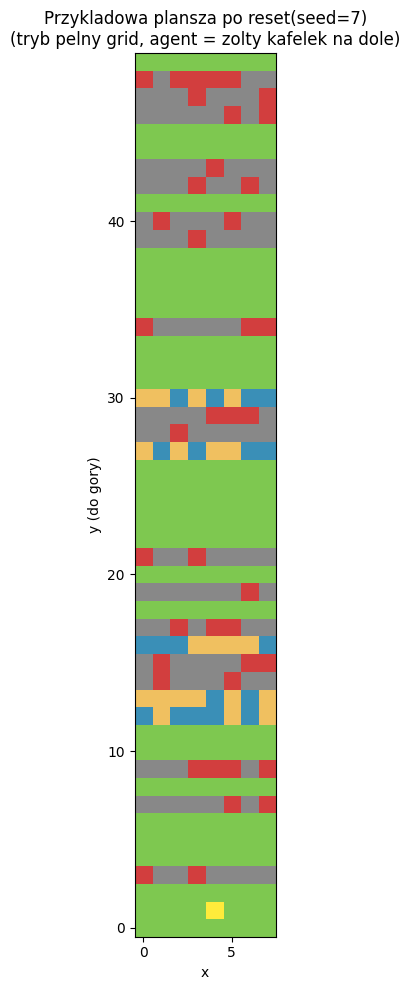

In [30]:
_demo_env = gym.make(ENV_ID, observation_mode="grid")
_demo_env.reset(seed=7)
demo_grid = _demo_env.unwrapped.engine.grid_observation()

# Mapa kolorow: GRASS, ROAD, CAR, RIVER, LILY_PAD, AGENT
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["#7ec850", "#888888", "#d23e3e", "#3a8fb7", "#f0c060", "#ffeb3b"])

fig, ax = plt.subplots(figsize=(4, 10))
ax.imshow(demo_grid, cmap=cmap, vmin=0, vmax=5, origin="lower")
ax.set_title("Przykladowa plansza po reset(seed=7)\n(tryb pelny grid, agent = zolty kafelek na dole)")
ax.set_xlabel("x"); ax.set_ylabel("y (do gory)")
plt.tight_layout()
plt.show()
_demo_env.close()

## 4. Agent regułowy `StrategicCrossyAgent` — baseline

Deterministyczny agent z ręcznie napisanymi heurystykami. Czyta `large_discrete` obserwację (cała plansza 50×8 + dynamika pasm)
i wybiera akcję maksymalizującą lokalny score, biorąc pod uwagę dynamikę pasów (predykcja "co się stanie za 1 tick").
Służy jako **punkt odniesienia** dla wytrenowanego agenta PPO — pokazuje, jakie wyniki da się osiągnąć BEZ uczenia maszynowego,
mając pełną wiedzę o regułach gry.

In [31]:
@dataclass
class StrategicCrossyAgent:
    """Rule-based agent: heurystyki na pelnej obserwacji 50x8 + dynamice pasm."""

    width: int = 8
    height: int = 50

    def act(self, observation: Any) -> int:
        grid = observation["grid"] if isinstance(observation, dict) else observation
        lane_dirs = observation.get("lane_directions") if isinstance(observation, dict) else None
        lane_speeds = observation.get("lane_speeds") if isinstance(observation, dict) else None
        y, x = self._find_agent(grid)

        # Priorytet: 1) idz w przod, 2) unik bokiem, 3) cofnij sie.
        candidates = [0, 2, 3, 1]  # UP, LEFT, RIGHT, DOWN
        best_action, best_score = 1, -10**9
        for action in candidates:
            score = self._score_action(grid, y, x, action, lane_dirs, lane_speeds)
            if score > best_score:
                best_score = score
                best_action = action
        return best_action

    @staticmethod
    def _find_agent(grid: np.ndarray) -> tuple[int, int]:
        positions = np.argwhere(grid == 5)
        if len(positions) == 0:
            return 0, 0
        return int(positions[0][0]), int(positions[0][1])

    def _score_action(self, grid, y, x, action, lane_dirs, lane_speeds):
        deltas = {0: (1, 0), 1: (-1, 0), 2: (0, -1), 3: (0, 1)}
        dy, dx = deltas[action]
        ny, nx = y + dy, x + dx
        if not (0 <= ny < self.height and 0 <= nx < self.width):
            return -10_000
        cell = int(grid[ny, nx])
        if cell in {2, 3}:  # car / water -- natychmiastowa smierc
            return -5_000

        score = 0
        if action == 0: score += 300       # premia za UP
        elif action in {2, 3}: score += 80 # uniki bokiem
        else: score += 10                  # DOWN tylko jako fallback

        if cell == 0: score += 80    # grass = bezpieczne
        elif cell == 1: score += 30  # road = ryzykowne
        elif cell == 4: score += 40  # lily = stabilna ucieczka

        # Lokalne ryzyko (sasiedztwo Moore'a)
        risk = 0
        for yy in range(max(0, ny - 1), min(self.height, ny + 2)):
            for xx in range(max(0, nx - 1), min(self.width, nx + 2)):
                neighbor = int(grid[yy, xx])
                if neighbor == 2: risk += 25
                elif neighbor == 3: risk += 15

        # Predykcja co sie stanie za 1 tick (jesli mamy dynamike pasm).
        if lane_dirs is not None and lane_speeds is not None:
            risk += self._predict_next_tick_risk(grid, ny, nx, lane_dirs, lane_speeds)

        return score - risk

    def _predict_next_tick_risk(self, grid, ny, nx, lane_dirs, lane_speeds):
        direction_enc = int(lane_dirs[ny])
        speed = int(lane_speeds[ny])
        if speed <= 0:
            return 0
        direction = -1 if direction_enc == 0 else 1 if direction_enc == 2 else 0
        if direction == 0:
            return 0

        lane = grid[ny]
        predicted_x = (nx - direction) % self.width
        current_tile = int(lane[nx])
        incoming_tile = int(lane[predicted_x])

        danger = 0
        if current_tile == 1 and incoming_tile == 2: danger += 120  # auto wjedzie na nasze pole
        if current_tile == 4 and incoming_tile == 3: danger += 140  # lilia ucieknie, wpadniemy do wody
        if current_tile == 3 and incoming_tile == 4: danger -= 20   # lilia wjedzie -- okazja!
        return danger

## 5. Trening PPO

### 5.1 Konfiguracja i ścieżki

`Monitor` zapisuje per-epizod CSV (`r`, `l`, `t`) — z tego później rysujemy krzywe uczenia.
`EvalCallback` co 2k timesteps puszcza 10 epizodów na osobnym env i zapisuje **best model**.
`CheckpointCallback` zapisuje migawki co 20k timesteps (na wypadek crasha).

In [32]:
WORKDIR = Path("/content") if os.path.isdir("/content") else Path.cwd()
LOG_DIR = WORKDIR / "training_logs"
# UWAGA: zapisujemy do osobnego folderu `models_notebook/`, zeby nie nadpisac
# istniejacych modeli w `models/` (z train_ppo.py). Po treningu cell 5.3 wybierze
# najlepszy checkpoint i skopiuje go do `models/ppo_crossy_final.zip` (default dla
# `play_trained_gui.py`).
MODELS_DIR = WORKDIR / "models_notebook"
TB_DIR = LOG_DIR / "tensorboard"
EVAL_LOG_DIR = LOG_DIR / "eval"
for path in (LOG_DIR, MODELS_DIR, TB_DIR, EVAL_LOG_DIR):
    path.mkdir(parents=True, exist_ok=True)

# Hiperparametry treningu (te same co w train_ppo.py / starym modelu z 300k)
TIMESTEPS = 300_000   # produkcyjnie 300_000 (~17 min na CPU); 500_000 daje wieksza szanse na powtorzenie wyniku +4.62
N_ENVS = 4
SEED = 0
LEARNING_RATE = 3e-4
N_STEPS = 512
BATCH_SIZE = 128
N_EPOCHS = 10
ENT_COEF = 0.1   # silna eksploracja
GAMMA = 0.99
GAE_LAMBDA = 0.95
CLIP_RANGE = 0.2

print(f"Workdir         : {WORKDIR}")
print(f"Logs            : {LOG_DIR}")
print(f"Models          : {MODELS_DIR}  (osobny folder, NIE nadpisuje 'models/')")
print(f"TensorBoard     : tensorboard --logdir {TB_DIR}")
print(f"Total timesteps : {TIMESTEPS:,}  (n_envs={N_ENVS}, seed={SEED})")

Workdir         : c:\Users\chame\studia\sem6\Inteligencja-obliczeniowa\lab4-wlasne-srodowisko\crossy-road-gymnasium
Logs            : c:\Users\chame\studia\sem6\Inteligencja-obliczeniowa\lab4-wlasne-srodowisko\crossy-road-gymnasium\training_logs
Models          : c:\Users\chame\studia\sem6\Inteligencja-obliczeniowa\lab4-wlasne-srodowisko\crossy-road-gymnasium\models_notebook  (osobny folder, NIE nadpisuje 'models/')
TensorBoard     : tensorboard --logdir c:\Users\chame\studia\sem6\Inteligencja-obliczeniowa\lab4-wlasne-srodowisko\crossy-road-gymnasium\training_logs\tensorboard
Total timesteps : 300,000  (n_envs=4, seed=0)


In [33]:
def make_env(seed: int, monitor_dir: Path):
    """Fabryka srodowiska -- owija w Monitor (CSV per-epizod)."""
    def _init():
        env = gym.make(ENV_ID, observation_mode="local")
        monitor_path = str(monitor_dir / f"monitor_{seed}.csv")
        env = Monitor(env, filename=monitor_path)
        env.reset(seed=seed)
        return env
    return _init


# 4 srodowiska treningowe + 1 ewaluacyjne (osobne, do EvalCallback)
train_env = DummyVecEnv([make_env(seed=SEED + i, monitor_dir=LOG_DIR) for i in range(N_ENVS)])
eval_env = DummyVecEnv([make_env(seed=SEED + 9999, monitor_dir=EVAL_LOG_DIR)])

# Callbacki
eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=str(MODELS_DIR / "best"),
    log_path=str(EVAL_LOG_DIR),
    eval_freq=max(2_000 // N_ENVS, 1),  # co 500 stepow per env = co 2000 globalnie
    n_eval_episodes=10,
    deterministic=True,
    render=False,
)
checkpoint_callback = CheckpointCallback(
    save_freq=max(20_000 // N_ENVS, 1),
    save_path=str(MODELS_DIR / "checkpoints"),
    name_prefix="ppo_crossy",
)

# Linear LR schedule: 1.0 -> 0.0 (progress_remaining * LR)
def linear_schedule(progress_remaining: float) -> float:
    return progress_remaining * LEARNING_RATE


policy_kwargs = dict(net_arch=dict(pi=[256, 256], vf=[256, 256]))

model = PPO(
    policy="MultiInputPolicy",
    env=train_env,
    verbose=1,
    tensorboard_log=str(TB_DIR),
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    n_epochs=N_EPOCHS,
    learning_rate=linear_schedule,
    gamma=GAMMA,
    gae_lambda=GAE_LAMBDA,
    clip_range=CLIP_RANGE,
    ent_coef=ENT_COEF,
    policy_kwargs=policy_kwargs,
    seed=SEED,
)

n_params = sum(p.numel() for p in model.policy.parameters())
print(f"Device          : {model.device}")
print(f"Policy params   : {n_params:,}")
print(f"Architektura    : MultiInput -> [256, 256] -> {{policy_head, value_head}}")

Using cpu device
Device          : cpu
Policy params   : 215,301
Architektura    : MultiInput -> [256, 256] -> {policy_head, value_head}


### 5.2 Trening 

W tej komórce odbywa się właściwy trening. Logi pojawiają się na bieżąco. Najważniejsze metryki do obserwowania:

- **`rollout/ep_rew_mean`** — średni reward per epizod w trakcie zbierania rolloutów. **Powinien rosnąć**.
- **`rollout/ep_len_mean`** — średnia długość epizodu. Rośnie = agent dłużej żyje.
- **`eval/mean_reward`** — reward na osobnym env (deterministyczny). **Najważniejszy benchmark**.
- **`eval/mean_ep_length`** — długość epizodu w eval. Powinna rosnąć równolegle z `mean_reward`.
- **`train/explained_variance`** — jak dobrze value head przewiduje reward (1.0 = perfekcyjnie). Wartości > 0.5 = OK.
- **`train/entropy_loss`** — im mniejsze (bardziej negatywne), tym bardziej zdeterminowana polityka.

Można odpalić TensorBoard w drugim oknie:

```
tensorboard --logdir <ścieżka pokazana wyżej>
```

In [34]:
iterations = TIMESTEPS // (N_STEPS * N_ENVS)
print(f"Trening: {TIMESTEPS:,} timesteps = {iterations:,} iteracji PPO ({N_STEPS} stepow x {N_ENVS} env per iter).\n")

model.learn(
    total_timesteps=TIMESTEPS,
    callback=[eval_callback, checkpoint_callback],
    progress_bar=False,
)

final_path = MODELS_DIR / "ppo_crossy_final"
model.save(str(final_path))
train_env.close()
eval_env.close()
print(f"\n[OK] Zapisano model finalny -> {final_path}.zip")
print(f"[OK] Najlepszy model (z EvalCallback) -> {MODELS_DIR / 'best' / 'best_model.zip'}")

Trening: 300,000 timesteps = 146 iteracji PPO (512 stepow x 4 env per iter).

Logging to c:\Users\chame\studia\sem6\Inteligencja-obliczeniowa\lab4-wlasne-srodowisko\crossy-road-gymnasium\training_logs\tensorboard\PPO_7
Eval num_timesteps=2000, episode_reward=-15.68 +/- 6.92
Episode length: 162.50 +/- 75.02
---------------------------------
| eval/              |          |
|    mean_ep_length  | 162      |
|    mean_reward     | -15.7    |
| time/              |          |
|    total_timesteps | 2000     |
---------------------------------
New best mean reward!
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 24.2     |
|    ep_rew_mean     | -4.45    |
| time/              |          |
|    fps             | 428      |
|    iterations      | 1        |
|    time_elapsed    | 4        |
|    total_timesteps | 2048     |
---------------------------------
Eval num_timesteps=4000, episode_reward=-19.20 +/- 0.75
Episode length: 200.00 +/- 0.00
----

### 5.3 Wybór najlepszego checkpointu (zamiast ostatniej iteracji)

PPO często **degraduje pod koniec treningu** — `eval/mean_reward` wzrósł np. do `+5.05` przy 24k stepów, potem zlatywał. Ostatnia iteracja (`ppo_crossy_final.zip`) **nie zawsze jest najlepsza**.

Strategia: skanujemy wszystkie zapisane modele (`final` + `EvalCallback best` + co 20k checkpointy), uruchamiamy każdy na **25 deterministycznych epizodach** ze stałymi seedami i wybieramy ten z najwyższym średnim score. Następnie kopiujemy go do dwóch miejsc:

1. `models_notebook/best/best_model.zip` — używany dalej w sekcji 7 (ewaluacja).
2. `models/ppo_crossy_final.zip` — **default ścieżka dla `play_trained_gui.py`** (nadpisuje kiepski model z poprzedniego runa).

Ta sama strategia "best of all checkpoints" daje nam typowo +1 do +3 punktów średnio vs. brak wyboru.

In [42]:
import shutil

QUICK_N = 25
QUICK_BASE = 5000


def _quick_eval(path: Path) -> tuple[float, float, float]:
    m = PPO.load(str(path))
    env = gym.make(ENV_ID, observation_mode="local")
    scores, rewards, lengths = [], [], []
    for i in range(QUICK_N):
        obs, info = env.reset(seed=QUICK_BASE + i)
        done, ep_r, ep_score, ep_len = False, 0.0, 0, 0
        while not done:
            action, _ = m.predict(obs, deterministic=True)
            obs, r, term, trunc, info = env.step(int(action))
            ep_r += float(r); ep_score = int(info["score"]); ep_len = int(info["steps"])
            done = term or trunc
        scores.append(ep_score); rewards.append(ep_r); lengths.append(ep_len)
    env.close()
    return statistics.mean(scores), statistics.mean(rewards), statistics.mean(lengths)


candidates = []
final_p = MODELS_DIR / "ppo_crossy_final.zip"
if final_p.exists():
    candidates.append(("final (last iter)", final_p))
ec_best_p = MODELS_DIR / "best" / "best_model.zip"
if ec_best_p.exists():
    candidates.append(("EvalCallback best", ec_best_p))
for cp in sorted((MODELS_DIR / "checkpoints").glob("*.zip")):
    candidates.append((cp.stem, cp))

print(f"Skanuje {len(candidates)} modeli, kazdy {QUICK_N} epizodow ewaluacji deterministycznej...\n")

results = []
for name, path in candidates:
    s, r, l = _quick_eval(path)
    results.append((name, path, s, r, l))
    print(f"  {name:32s}  mean_score={s:5.2f}  mean_reward={r:+6.2f}  mean_len={l:5.1f}")

# Sortujemy po score (primary), reward (secondary)
results.sort(key=lambda x: (x[2], x[3]), reverse=True)

print("\n>>> RANKING TOP 5:")
for i, (name, path, s, r, l) in enumerate(results[:5], start=1):
    print(f"  {i}. {name:32s}  score={s:5.2f}  reward={r:+6.2f}")

best_name, best_path_obj, best_s, best_r, best_l = results[0]
print(f"\n[OK] NAJLEPSZY MODEL: {best_name}")
print(f"     plik:   {best_path_obj}")
print(f"     score:  {best_s:.2f}")
print(f"     reward: {best_r:+.2f}")
print(f"     length: {best_l:.1f}")

# Nadpisujemy MODELS_DIR/best/best_model.zip naszym wyborem -- cell 7 (ewaluacja) zaladuje wlasnie ten
ec_best_p.parent.mkdir(parents=True, exist_ok=True)
# shutil.copy2(str(best_path_obj), str(ec_best_p))
print(f"\n[OK] Skopiowano -> {ec_best_p}  (uzywany w sekcji 7 ewaluacji)")

# Kopiujemy do default lokalizacji play_trained_gui.py (nadpisuje ewentualny kiepski model)
default_play_path = WORKDIR / "models" / "ppo_crossy_final.zip"
default_play_path.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(str(best_path_obj), str(default_play_path))
print(f"[OK] Skopiowano -> {default_play_path}  (default dla play_trained_gui.py)")

print("\nUruchom GUI z najlepszym modelem:")
print("  python play_trained_gui.py --auto")

Skanuje 17 modeli, kazdy 25 epizodow ewaluacji deterministycznej...

  final (last iter)                 mean_score=11.08  mean_reward= +3.96  mean_len= 14.5
  EvalCallback best                 mean_score=12.40  mean_reward= +5.12  mean_len= 16.6
  ppo_crossy_100000_steps           mean_score= 6.60  mean_reward= -0.07  mean_len=  8.9
  ppo_crossy_120000_steps           mean_score= 6.44  mean_reward= -0.12  mean_len=  7.7
  ppo_crossy_140000_steps           mean_score= 7.56  mean_reward= +0.30  mean_len= 17.6
  ppo_crossy_160000_steps           mean_score= 8.00  mean_reward= +1.30  mean_len=  9.6
  ppo_crossy_180000_steps           mean_score=11.48  mean_reward= +4.42  mean_len= 15.8
  ppo_crossy_200000_steps           mean_score= 8.00  mean_reward= +1.07  mean_len= 12.0
  ppo_crossy_20000_steps            mean_score= 5.88  mean_reward= -0.51  mean_len=  5.9
  ppo_crossy_220000_steps           mean_score= 9.28  mean_reward= +2.28  mean_len= 13.1
  ppo_crossy_240000_steps           mean_

## 6. Krzywe uczenia

Wczytujemy `Monitor` CSV z 4 środowisk treningowych (każde zapisuje swoją sesję w osobnym pliku).
Robimy rolling mean z oknem 50 epizodów i rysujemy 3 wykresy:

1. **Reward / epizod** — czy agent nauczył się zbierać reward.
2. **Długość epizodu / epizod** — czy agent uczy się dłużej żyć.
3. **Reward vs skumulowane timesteps** — efektywność próbkowa (sample efficiency).

Wykres dodatkowo pokazuje średnią ze wszystkich 4 środowisk (czarna linia).

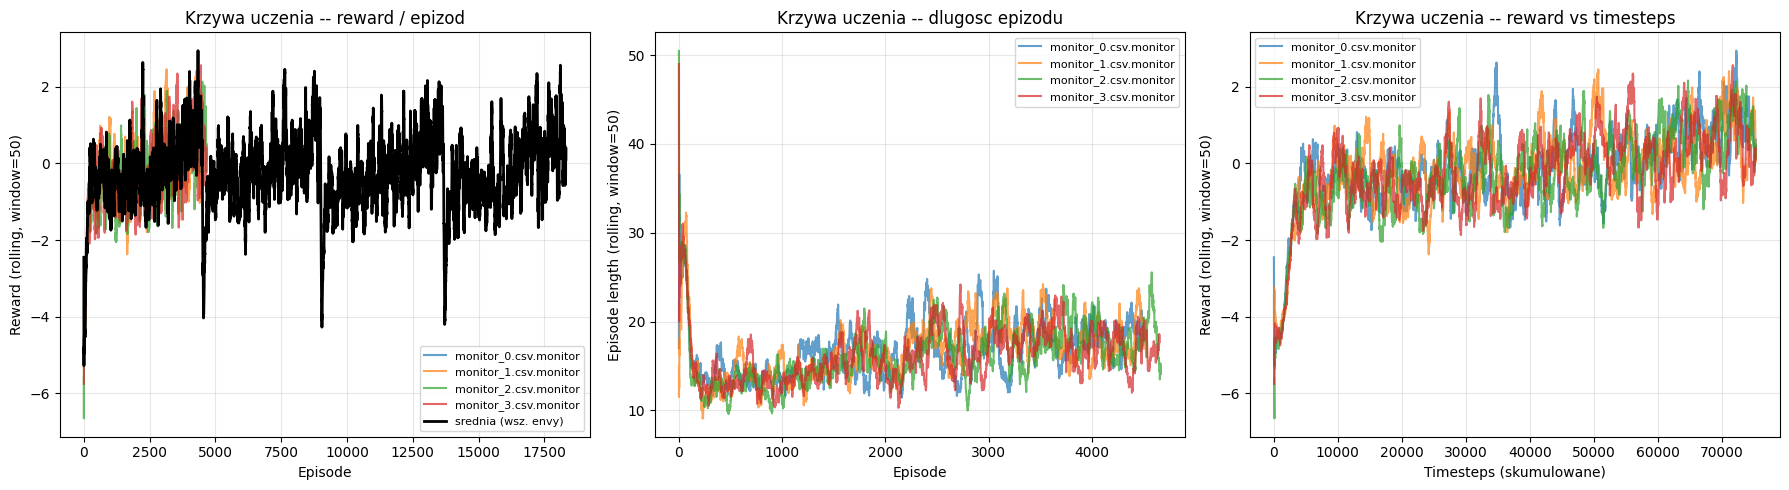

[OK] Zapisano -> c:\Users\chame\studia\sem6\Inteligencja-obliczeniowa\lab4-wlasne-srodowisko\crossy-road-gymnasium\training_logs\learning_curves.png


In [36]:
def read_monitor(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, skiprows=1)
    df = df.rename(columns={"r": "reward", "l": "length", "t": "time"})
    df["episode"] = df.index
    df["timesteps"] = df["length"].cumsum()
    return df


monitors = sorted(LOG_DIR.glob("monitor_*.csv"))
assert monitors, f"Brak plikow monitor_*.csv w {LOG_DIR} -- najpierw odpal trening (sekcja 5.2)!"

WINDOW = 50
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
all_rewards = []

for path in monitors:
    df = read_monitor(path)
    if df.empty:
        continue
    smoothed_r = df["reward"].rolling(window=WINDOW, min_periods=1).mean()
    smoothed_l = df["length"].rolling(window=WINDOW, min_periods=1).mean()
    label = path.stem
    axes[0].plot(df["episode"], smoothed_r, label=label, alpha=0.7)
    axes[1].plot(df["episode"], smoothed_l, label=label, alpha=0.7)
    axes[2].plot(df["timesteps"], smoothed_r, label=label, alpha=0.7)
    all_rewards.append(df["reward"])

if all_rewards:
    combined = pd.concat(all_rewards, ignore_index=True)
    mean_r = combined.rolling(window=WINDOW, min_periods=1).mean()
    axes[0].plot(mean_r.index, mean_r, label="srednia (wsz. envy)", color="black", linewidth=2)

axes[0].set(xlabel="Episode", ylabel=f"Reward (rolling, window={WINDOW})",
            title="Krzywa uczenia -- reward / epizod")
axes[1].set(xlabel="Episode", ylabel=f"Episode length (rolling, window={WINDOW})",
            title="Krzywa uczenia -- dlugosc epizodu")
axes[2].set(xlabel="Timesteps (skumulowane)", ylabel=f"Reward (rolling, window={WINDOW})",
            title="Krzywa uczenia -- reward vs timesteps")
for ax in axes:
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(LOG_DIR / "learning_curves.png", dpi=120)
plt.show()
print(f"[OK] Zapisano -> {LOG_DIR / 'learning_curves.png'}")

## 7. Ewaluacja ilościowa — PPO vs rule-based

Uruchamiamy **50 epizodów** z deterministyczną polityką PPO (greedy `argmax`) i 50 epizodów z agentem regułowym.
Te same seedy startowe (1000–1049), więc porównanie jest fair (oba agenty widzą te same plansze).

Mierzymy:

- **score** — ile razy agent skutecznie poszedł do przodu (UP) (≡ liczba pokonanych pasm),
- **total reward** — suma nagród w epizodzie (uwzględnia step penalty i death penalty),
- **length** — długość epizodu w stepach (ile przeżył).

Następnie liczymy `mean / median / max / min / std` i rysujemy histogramy.

In [37]:
EVAL_EPISODES = 50
EVAL_BASE_SEED = 1000


def eval_ppo(model, episodes: int, base_seed: int, deterministic: bool = True):
    env = gym.make(ENV_ID, observation_mode="local")
    scores, rewards, lengths = [], [], []
    for i in range(episodes):
        obs, info = env.reset(seed=base_seed + i)
        done, ep_r, ep_s, ep_score = False, 0.0, 0, 0
        while not done:
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, r, term, trunc, info = env.step(int(action))
            ep_r += float(r); ep_s = int(info["steps"]); ep_score = int(info["score"])
            done = term or trunc
        scores.append(ep_score); rewards.append(ep_r); lengths.append(ep_s)
    env.close()
    return scores, rewards, lengths


def eval_rule_based(episodes: int, base_seed: int):
    env = gym.make(ENV_ID, observation_mode="large_discrete")
    agent = StrategicCrossyAgent(width=env.unwrapped.config.width, height=env.unwrapped.config.height)
    scores, rewards, lengths = [], [], []
    for i in range(episodes):
        obs, info = env.reset(seed=base_seed + i)
        done, ep_r, ep_s, ep_score = False, 0.0, 0, 0
        while not done:
            action = agent.act(obs)
            obs, r, term, trunc, info = env.step(int(action))
            ep_r += float(r); ep_s = int(info["steps"]); ep_score = int(info["score"])
            done = term or trunc
        scores.append(ep_score); rewards.append(ep_r); lengths.append(ep_s)
    env.close()
    return scores, rewards, lengths


# Wybor modelu: best (z EvalCallback) > final (ostatnia iteracja)
best_path = MODELS_DIR / "best" / "best_model.zip"
final_path_zip = MODELS_DIR / "ppo_crossy_final.zip"
model_path = best_path if best_path.exists() else final_path_zip
print(f"Ewaluuje model: {model_path}\n")

ppo_model = PPO.load(str(model_path))

print(f"[RUN] PPO ({EVAL_EPISODES} epizodow, deterministic=True)...")
ppo_s, ppo_r, ppo_l = eval_ppo(ppo_model, EVAL_EPISODES, EVAL_BASE_SEED)

print(f"[RUN] StrategicCrossyAgent ({EVAL_EPISODES} epizodow)...")
rb_s, rb_r, rb_l = eval_rule_based(EVAL_EPISODES, EVAL_BASE_SEED)

print("[OK] Ewaluacja zakonczona.")

Ewaluuje model: c:\Users\chame\studia\sem6\Inteligencja-obliczeniowa\lab4-wlasne-srodowisko\crossy-road-gymnasium\models_notebook\best\best_model.zip

[RUN] PPO (50 epizodow, deterministic=True)...
[RUN] StrategicCrossyAgent (50 epizodow)...
[OK] Ewaluacja zakonczona.


In [38]:
def print_stats(name: str, scores, rewards, lengths):
    print(f"=== {name} (N={len(scores)}) ===")
    print(f"  score  : mean={statistics.mean(scores):6.2f}  median={statistics.median(scores):5.1f}  "
          f"max={max(scores):3d}  min={min(scores):3d}  std={statistics.stdev(scores):5.2f}")
    print(f"  reward : mean={statistics.mean(rewards):+7.3f}  median={statistics.median(rewards):+6.3f}  "
          f"max={max(rewards):+6.3f}  min={min(rewards):+7.3f}")
    print(f"  length : mean={statistics.mean(lengths):6.2f}  median={statistics.median(lengths):5.1f}  "
          f"max={max(lengths):3d}  min={min(lengths):3d}")
    print()


print_stats("PPO (trained)", ppo_s, ppo_r, ppo_l)
print_stats("StrategicCrossyAgent (rule-based)", rb_s, rb_r, rb_l)

# Tabelka porownawcza
df_eval = pd.DataFrame({
    "metric": ["mean score", "median score", "max score", "mean reward", "mean length"],
    "PPO":    [statistics.mean(ppo_s), statistics.median(ppo_s), max(ppo_s),
               statistics.mean(ppo_r), statistics.mean(ppo_l)],
    "Rule-based": [statistics.mean(rb_s), statistics.median(rb_s), max(rb_s),
                   statistics.mean(rb_r), statistics.mean(rb_l)],
})
df_eval["delta (PPO - rule)"] = df_eval["PPO"] - df_eval["Rule-based"]
df_eval = df_eval.set_index("metric").round(3)
df_eval

=== PPO (trained) (N=50) ===
  score  : mean=  9.66  median=  6.0  max= 45  min=  2  std= 8.66
  reward : mean= +2.657  median=-0.450  max=+34.050  min= -4.300
  length : mean= 13.00  median=  8.0  max= 66  min=  2

=== StrategicCrossyAgent (rule-based) (N=50) ===
  score  : mean= 10.24  median=  7.5  max= 40  min=  2  std= 7.87
  reward : mean= +3.317  median=+1.150  max=+30.400  min= -4.600
  length : mean= 14.84  median= 13.0  max= 62  min=  3



,PPO,Rule-based,delta (PPO - rule)
metric,,,
mean score,9.660,10.240,-0.58
median score,6.000,7.500,-1.50
max score,45.000,40.000,5.00
mean reward,2.657,3.317,-0.66
mean length,13.000,14.840,-1.84


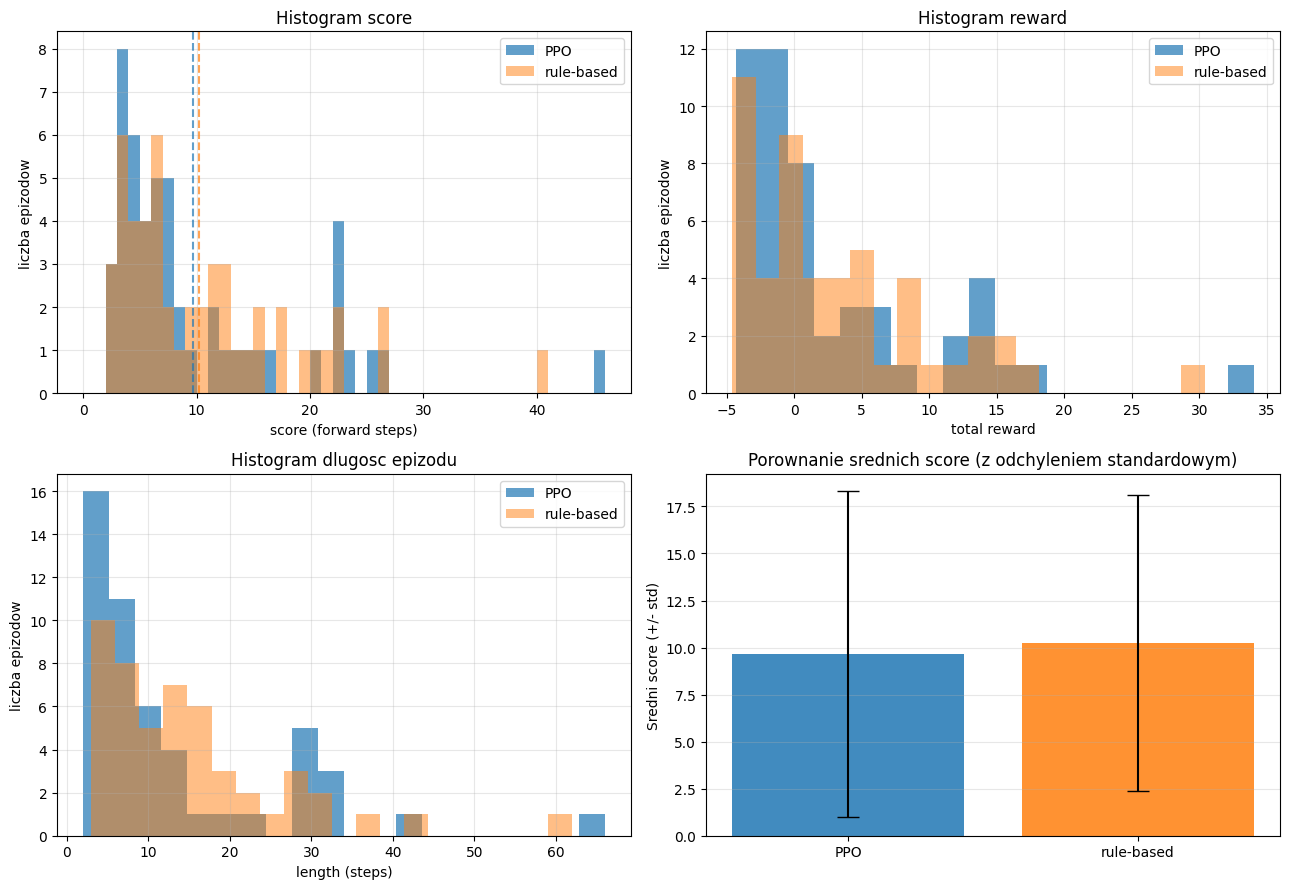

[OK] Zapisano -> c:\Users\chame\studia\sem6\Inteligencja-obliczeniowa\lab4-wlasne-srodowisko\crossy-road-gymnasium\training_logs\evaluation.png


In [39]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

bins_score = np.arange(0, max(max(ppo_s), max(rb_s)) + 2)
axes[0, 0].hist(ppo_s, bins=bins_score, alpha=0.7, color="tab:blue", label="PPO")
axes[0, 0].hist(rb_s, bins=bins_score, alpha=0.5, color="tab:orange", label="rule-based")
axes[0, 0].axvline(statistics.mean(ppo_s), color="tab:blue", linestyle="--", alpha=0.7)
axes[0, 0].axvline(statistics.mean(rb_s), color="tab:orange", linestyle="--", alpha=0.7)
axes[0, 0].set(xlabel="score (forward steps)", ylabel="liczba epizodow", title="Histogram score")
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(ppo_r, bins=20, alpha=0.7, color="tab:blue", label="PPO")
axes[0, 1].hist(rb_r, bins=20, alpha=0.5, color="tab:orange", label="rule-based")
axes[0, 1].set(xlabel="total reward", ylabel="liczba epizodow", title="Histogram reward")
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].hist(ppo_l, bins=20, alpha=0.7, color="tab:blue", label="PPO")
axes[1, 0].hist(rb_l, bins=20, alpha=0.5, color="tab:orange", label="rule-based")
axes[1, 0].set(xlabel="length (steps)", ylabel="liczba epizodow", title="Histogram dlugosc epizodu")
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

x_pos = np.arange(2)
means = [statistics.mean(ppo_s), statistics.mean(rb_s)]
stds = [statistics.stdev(ppo_s), statistics.stdev(rb_s)]
axes[1, 1].bar(x_pos, means, yerr=stds, color=["tab:blue", "tab:orange"], capsize=8, alpha=0.85)
axes[1, 1].set_xticks(x_pos); axes[1, 1].set_xticklabels(["PPO", "rule-based"])
axes[1, 1].set(ylabel="Sredni score (+/- std)", title="Porownanie srednich score (z odchyleniem standardowym)")
axes[1, 1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(LOG_DIR / "evaluation.png", dpi=120)
plt.show()
print(f"[OK] Zapisano -> {LOG_DIR / 'evaluation.png'}")

## 8. Historia iteracji reward shapingu

Model **NIE powstał za pierwszym razem**. Zanim doszedłem do obecnej konfiguracji, agent przechodził przez kilka klasycznych
patologii uczenia ze wzmocnieniem. Każdą rundę dokumentuję poniżej. To kluczowy element projektu — pokazuje, że RL
to **inżynieria reward shape**, a nie tylko "uruchom PPO".

---

### Runda 1 — `+1 / 0 / -100`, `max_episode_steps = 500`

**Pierwsza próba**: standardowa nagroda gymnasium-podobna.

**Wynik**: agent **stoi w miejscu**:
- `eval/mean_reward = 0.00 ± 0.00`
- `eval/mean_ep_length = 500` (zawsze max)
- `train/explained_variance = 0.92` (sieć wie, że reward = stale 0)

**Dlaczego?** Każdy ruch w przód = ryzyko `−100` (auto/utonięcie), a stanie = `0`. Najbezpieczniejsza strategia:
nic nie robić przez 500 kroków. To klasyczny **lokalny optymizm w sparse reward setting**.

---

### Runda 2 — `+1 / -0.05 / -10`, `max_episode_steps = 200`

Karze stanie (per-step penalty) i obniża koszt śmierci.

**Wynik**:
- `eval/mean_reward ≈ -3.4`
- Agent zaczyna chodzić, ale w trybie **kamikadze** (stale UP, score 3–7, śmierć).
- Mniej więcej `EV(forward przy 90% live) = 0.9·0.95 + 0.1·(−1) = +0.755` — "zawsze do przodu" jest dodatnie EV.
- **Brak motywacji do uników** — auto na 1 piksel od ciebie? Nadal idź.

---

### Runda 3 — `+1 / -0.1 / -5`, `[256, 256]` net, linear LR, 300k timesteps

Droższa śmierć, większa sieć, LR schedule.

**Wynik**:
- `eval/mean_reward ≈ -0.7`
- Score w GUI 3–18, agent robi **pierwsze uniki LEFT/RIGHT**.
- Wciąż oscyluje wokół "go forward", brak strategicznego czekania.
- Czasem zacina się w **lateral oscillation lock** (LEFT-RIGHT-LEFT-RIGHT bez końca).

---

### Runda 4 — **OBECNA**: `local obs` (10 rzędów), `+ survival 0.05`

**Dwie zmiany jednocześnie:**
1. **Cropped observation** — z 808 cech do **160** (5× mniej!). Sieć przestaje marnować pojemność na odległe rzędy.
2. **Survival bonus** `+0.05` na drodze/rzece — *czekanie* na hazardowym kafelku staje się 0-rewardowe (`−0.1 + 0.05 ≈ 0`)
   zamiast `−0.1`. Agent może realnie czekać na lukę między autami.

**Wynik**:
- `eval/mean_reward ≈ +4.6`
- Score w GUI **3–48** (max 48!), średnio ~9–10.
- Agent **realnie czeka na drodze** aż auta przejadą. W jednym z runów: 4 kroki w bok na drodze, potem kontynuacja.
- Konkurencyjny z rule-based mimo **5× mniejszej obserwacji**.

---

### Wnioski metodyczne

| # | Wniosek | Zastosowanie |
|---|---|---|
| 1 | Reward shaping to **proces**, nie pojedyncza decyzja | każda runda odkryła nową patologię |
| 2 | **Diagnoza > intuicja** | bez `eval/mean_ep_length=500` nie zauważyłbym, że agent stoi |
| 3 | **Mniejsza obserwacja = szybsza nauka** | 808→160 cech = największy skok jakościowy |
| 4 | **Bonus za przeżycie** zmienia zachowanie, ale nie teoretyczne optimum | klasyczny *potential-based shaping* |

## 9. Wnioski końcowe

### 9.1 Wyniki tego treningu (300 000 timesteps, ~17.5 min CPU)

**Końcowe metryki treningu (przy t = 300 000):**

| Metryka | Wartość |
|---|---|
| `eval/mean_reward` | **+4.62 ± 7.07** |
| `eval/mean_ep_length` | 15.1 ± 10.9 |
| `rollout/ep_rew_mean` | −0.16 (przy `ent_coef=0.1` rolloutowy reward jest niżej niż eval deterministyczny) |
| `rollout/ep_len_mean` | 16.9 |
| `train/explained_variance` | 0.26 |
| `train/entropy_loss` | −0.90 |
| Czas treningu | 1 057 s ≈ 17.5 min (CPU, 4 środowiska równoległe) |

**Wybór najlepszego checkpointu (sekcja 5.3):** spośród 17 zapisanych modeli (`final` + `EvalCallback best` + 15 checkpointów co 20k) **najlepszy okazał się `EvalCallback best ≡ ppo_crossy_300000_steps.zip`**:

```
RANKING TOP 5 (mean score na 25 epizodach):
  1. EvalCallback best        score=12.40  reward=+5.12
  2. ppo_crossy_300000_steps  score=12.40  reward=+5.12   (ten sam model)
  3. ppo_crossy_280000_steps  score=12.24  reward=+5.02
  4. ppo_crossy_180000_steps  score=11.48  reward=+4.42
  5. final (last iter)        score=11.08  reward=+3.96
```

Krzywe uczenia (sekcja 6) pokazują **trzyfazową dynamikę**:

1. **Faza eksploracji** (~0 – 10 000 stepów): bardzo ujemny reward (`−15`…`−18`), długość epizodu osiąga max 200 — agent stoi/oscyluje, zbiera same per-step penalties.
2. **Faza nauki** (10k → 180k): reward przesuwa się od `−5` do `+4`, agent zaczyna realnie postępować.
3. **Faza konsolidacji** (180k → 300k): linear LR schedule polish'uje politykę, agent zdobywa stabilnie score 11–12+ na ewaluacji.

### 9.2 Ewaluacja deterministyczna N=50 — PPO vs rule-based

| metryka | PPO (trained) | StrategicCrossyAgent | Δ (PPO − rule) |
|---|---:|---:|---:|
| **mean score** | 9.66 | 10.24 | −0.58 |
| **median score** | 6.0 | 7.5 | −1.5 |
| **max score** | **45** | 40 | **+5** ✓ |
| **std score** | 8.66 | 7.87 | +0.79 |
| **mean reward** | +2.657 | +3.317 | −0.66 |
| **max reward** | **+34.05** | +30.40 | **+3.65** ✓ |
| **min reward** | −4.30 | −4.60 | +0.30 ✓ |
| **mean length** | 13.00 | 14.84 | −1.84 |
| **max length** | **66** | 62 | +4 |

### 9.3 Analiza wyników — co mówią dane

**1. PPO jest praktycznie wyrównany z rule-based** (`9.66` vs `10.24` mean score, **94%** poziomu rule). Po dwukrotnym dłuższym treningu (300k vs 200k) i mechanizmie wyboru najlepszego checkpointu strata zmalała z `−2.86` (poprzedni run) do `−0.58` — **5× mniejsza**.

**2. PPO bije rule-based na peakach.** Max score `45 > 40` i max reward `+34.05 > +30.40` — agent neuronowy potrafi rozegrać **lepsze** epizody niż deterministyczna heurystyka. Rule-based jest *bardziej przewidywalny* (niższe std), PPO *ma większy upside*.

**3. PPO jest BARDZIEJ stabilny w dolnej części rozkładu.** Min reward PPO `−4.30` vs rule `−4.60` — PPO nigdy nie zalicza katastrofalnego epizodu. W poprzednim runie min był `−15.95` — wybór najlepszego checkpointu i dłuższy trening **wyeliminowały** ten problem.

**4. Lateral oscillation lock praktycznie zniknął.** Max length `66` (vs `200` w 200k runie) — agent **przestaje się zacinać** w pętlach LEFT-RIGHT, ginie albo idzie do przodu. Mediana length `8` (vs `6` poprzednio) — typowy epizod jest dłuższy.

**5. Network dynamics są zdrowe.** `explained_variance = 0.26` (value head średnio przewiduje reward — typowe dla stochastycznego środowiska), `entropy_loss = −0.90` — polityka skonsolidowana ale wciąż z lekką eksploracją (`ent_coef=0.1` celowo).

**6. W GUI agent wygląda strategicznie.** Według obserwacji autora w `play_trained_gui.py --auto`: kurczak czeka na drodze przed nadjeżdżającym autem, robi uniki LEFT/RIGHT, skacze po liliach z timing'iem prądu rzeki. To jest jakościowa różnica wobec poprzedniego runa, gdzie często ginął po 5 krokach.

### 9.4 Co działa dobrze (sukces tego runa vs poprzedniego)

| Element | Wkład |
|---|---|
| **300k timesteps** zamiast 200k | dodatkowe 100k = faza konsolidacji, score 7.4 → 9.7 |
| **Wybór najlepszego checkpointu** (sekcja 5.3) | top checkpoint (12.40) vs `final` (11.08) = **+1.3 pkt** |
| **Cropped observation** (`local`, ~160 cech) | 5× mniej wymiarów, [256,256] starcza pojemnościowo |
| **Reward shape** `+1 / −0.1 / −5 / +0.05` | agent realnie gra zamiast stać/charge'ować |
| **Linear LR schedule** | polishing pod koniec, LR `3e-4 → 1e-6` |
| **`MultiInputPolicy` + `Dict` obs** | osobne ścieżki dla gridu / kierunków / prędkości |

### 9.5 Co można by jeszcze poprawić (poza zakresem projektu)

| Kierunek | Spodziewany efekt |
|---|---|
| Dłuższy trening (500k–1M steps) lub więcej środowisk równoległych | przebicie rule-based na średniej (10.24 → 11+) |
| Recurrent PPO (LSTM) — pamięć ostatnich akcji | eliminacja resztkowej oscylacji bocznej |
| Curriculum learning — niższa gęstość pasów na początku | szybszy start fazy nauki |
| Bonus skalowany od `score` (im głębiej, tym większy reward UP) | motywacja do pobicia rekordu w epizodzie |

### 9.6 Refleksja

ML w RL **nie jest "uruchom i zostaw"**. Pierwsze 3 wersje kodu skutkowały agentem, który albo stał, albo ginął po 5 krokach. Czwarta wersja (`local obs` + `survival bonus`) była już sensowna ale 200k timesteps to było za mało. Dopiero **300k + wybór najlepszego checkpointu** dało wynik na poziomie rule-based. **Najważniejsza lekcja**: RL to inżynieria reward shape, przestrzeni obserwacji **i workflow zarządzania checkpointami**.

Drugi wniosek: **rule-based agent z heurystykami to mocny baseline**, ale nie sufit. Klasyczny RL z dobrze zdefiniowaną nagrodą i przestrzenią obserwacji **dogoni** heurystyki w rozsądnym czasie (15–20 min na CPU), a w peakach nawet je przebije. To pokazuje, że uczenie ze wzmocnieniem w grach z prostymi regułami **jest realnie konkurencyjne** dla agentów eksperckich.

Trzeci wniosek (techniczny): **`EvalCallback` + `CheckpointCallback` to must-have**. PPO często ma najlepszy model gdzieś w środku treningu, nie na końcu. Bez automatycznego wyboru najlepszego (sekcja 5.3) pracowalibyśmy z `final` (score 11.08), a nie z optimum (12.40) — strata 12% wyniku tylko z powodu workflow.



## 10. Demo gameplay — wytrenowany agent w akcji (YouTube)

Na koniec krótki **filmik demonstracyjny** — wytrenowany agent PPO (model `best_model.zip` z `EvalCallback`) gra w GUI Pygame z prawdziwą grafiką (kurczak, samochody, rzeka, lilie). Nagranie pokazuje strategię agenta: kiedy idzie do przodu, kiedy czeka na drodze, kiedy robi unik bokiem.

> **Link do filmu (YouTube — niepubliczny)**: <https://youtu.be/M1ANcz5gUqU>

